In [1]:
from datasets import get_benchmark_for_task
from scripts.transformer_prediction_interface.base import FairPFNClassifier
from scripts.tabular_metrics import causal_fairness_total_effect, roc_auc_score


task_type = "fairness_multiclass"
if "datasets_dict" not in locals():
    datasets_dict = {}

datasets_dict[f"valid_{task_type}"], df = get_benchmark_for_task(
    task_type,
    split="valid",
    max_samples=10000,
    return_as_lists=False,
    sel=False
)

dataset_map = {}
for dataset in datasets_dict[f"valid_{task_type}"]:
    dataset_map[dataset.name] = dataset

fairpfn = FairPFNClassifier()

dataset = dataset_map['Total_effect_lawschool'] 
train_ds, test_ds = dataset.generate_valid_split(n_splits=2)


########### Causal Case Studies ###########


Fair Additive Noise Benchmarks: 100%|██████████| 100/100 [00:00<00:00, 156.42it/s]



########### Causal Case Studies (Counterfactual) ###########


Fair Additive Noise Benchmarks: 100%|██████████| 100/100 [00:00<00:00, 200.17it/s]



########### Real-World Data ###########
Law School Admissions
Adult Census Income

########### Real-World Data (Counterfactual) ###########
Law School Admissions
Adult Census Income

########### Loading FairPFN Model ###########


In [8]:
#print the names of the datasets
print("Datasets:")
for dataset in datasets_dict[f"valid_{task_type}"]:
    print(dataset.name)

Datasets:
Direct_effect_0
Direct_effect_1
Direct_effect_2
Direct_effect_3
Direct_effect_4
Direct_effect_5
Direct_effect_6
Direct_effect_7
Direct_effect_8
Direct_effect_9
Direct_effect_10
Direct_effect_11
Direct_effect_12
Direct_effect_13
Direct_effect_14
Direct_effect_15
Direct_effect_16
Direct_effect_17
Direct_effect_18
Direct_effect_19
Direct_effect_20
Direct_effect_21
Direct_effect_22
Direct_effect_23
Direct_effect_24
Direct_effect_25
Direct_effect_26
Direct_effect_27
Direct_effect_28
Direct_effect_29
Direct_effect_30
Direct_effect_31
Direct_effect_32
Direct_effect_33
Direct_effect_34
Direct_effect_35
Direct_effect_36
Direct_effect_37
Direct_effect_38
Direct_effect_39
Direct_effect_40
Direct_effect_41
Direct_effect_42
Direct_effect_43
Direct_effect_44
Direct_effect_45
Direct_effect_46
Direct_effect_47
Direct_effect_48
Direct_effect_49
Direct_effect_50
Direct_effect_51
Direct_effect_52
Direct_effect_53
Direct_effect_54
Direct_effect_55
Direct_effect_56
Direct_effect_57
Direct_effect_

### Show data

In [ ]:
#print first 10 records of the train_ds and test_ds
print("\nFirst 10 records of the train_ds:")
print(train_ds.x[:10])
print(train_ds.y[:10])  
print("\nFirst 10 records of the test_ds:")
print(test_ds.x[:10])
print(test_ds.y[:10])  


First 10 records of the train_ds:
tensor([[ 1.0000e+00,  0.0000e+00,  3.0000e+00,  3.6000e+01, -3.1417e-01,
         -1.0740e-01],
        [ 1.0000e+00,  1.0000e+00,  3.1000e+00,  3.0000e+01, -8.7740e-02,
         -7.0620e+00],
        [ 0.0000e+00,  1.0000e+00,  2.2000e+00,  3.9000e+01, -7.9160e-01,
          7.9003e+00],
        [ 1.0000e+00,  0.0000e+00,  3.4000e+00,  3.7000e+01,  8.5834e-02,
          9.9800e-02],
        [ 1.0000e+00,  0.0000e+00,  3.6000e+00,  3.0500e+01,  2.8583e-01,
         -7.0086e+00],
        [ 1.0000e+00,  1.0000e+00,  3.6000e+00,  3.6000e+01,  4.1226e-01,
         -2.4487e+00],
        [ 1.0000e+00,  0.0000e+00,  2.6000e+00,  3.7000e+01, -7.1417e-01,
          1.1038e+00],
        [ 1.0000e+00,  1.0000e+00,  3.6000e+00,  3.1000e+01,  4.1226e-01,
         -7.4487e+00],
        [ 1.0000e+00,  1.0000e+00,  3.2000e+00,  4.1000e+01,  1.2260e-02,
          3.7364e+00],
        [ 1.0000e+00,  0.0000e+00,  3.2000e+00,  3.5000e+01, -1.1417e-01,
         -1.4290e+

### Next part

In [4]:
fairpfn.fit(train_ds.x, train_ds.y)
y_pred = fairpfn.predict_proba(test_ds.x)

print("\n############ Calculating ATE and AUC ###############")
ate = causal_fairness_total_effect(target=test_ds.y, pred=y_pred, x=test_ds.x, prot_attr=test_ds.x[:, 0], name=test_ds.name, dowhy_data=test_ds.dowhy_data)
auc = roc_auc_score(test_ds.y, y_pred[:,1])
print(f'ATE: {round(ate, 3)}, AUC: {round(auc, 3)}')


Could not determine size of memory of this system, using default 8 GB


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]


############ Calculating ATE and AUC ###############


c:\Users\patri\anaconda3\envs\fairpfn_env\lib\site-packages\dowhy\causal_model.py:613: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  logger.warn(


ATE: 0.0, AUC: 0.618


### PKL setting file configuration:

In [5]:
import pickle
from pathlib import Path

# 1. Point to the corrected config file path
config_file = Path("artifacts/fairpfn_config.pkl")

# 2. Load the object into memory
with open(config_file, 'rb') as f:
    config_data = pickle.load(f)

#Print content of pickle file
for name, value in vars(config_data).items():
    print(f"{name}: {value}")
    

#inspect attributes:
print(type(config_data.paths_config))


print("\nPaths Config:")
for name, value in vars(config_data.paths_config).items():
    print(f"{name}: {value}")

task_type: multiclass
model_type: single
paths_config: TabPFNModelPathsConfig(paths=['results/models_diff/model_submitit_0c_id_e3e764c1_epoch_-1.cpkt'], model_strings=['results/models_diff/model_submitit_0c_id_e3e764c1_epoch_-1.cpkt'], task_type='fairness_multiclass')
task_type_config: TabPFNClassificationConfig(multiclass_decoder='shuffle')
model_type_config: None
model_name: tabpfn_single_fast_v_2_1
preprocess_transforms: (PreprocessorConfig(name='safepower', categorical_name='numeric', append_original=True), PreprocessorConfig(name='power', categorical_name='numeric', append_original=True))
regression_y_preprocess_transforms: (None,)
feature_shift_decoder: shuffle
normalize_with_test: False
fp16_inference: True
N_ensemble_configurations: 1
average_logits: True
transformer_predict_kwargs: {}
save_peak_memory: True
batch_size_inference: None
max_poly_features: 50
use_poly_features: True
softmax_temperature: -0.10536051565782628
random_feature_scaling_strength: 0.0
auxiliary_clf: None


### Synthetic data trial

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from scripts.transformer_prediction_interface.base import FairPFNClassifier

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
print("Loading and formatting synthetic dataset...")
file_path = "synthetic_data/SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_0_8_nodes_full_data.csv"
df = pd.read_csv(file_path)

# Extract Target (Y)
y_train = df['Y'].values

# Extract Protected Attribute - Keeping only S0
A_train = df[['S0']]

# Extract Observable Features (X) - Dropping S1 and S2
X_features = df[['X3', 'X4', 'X5', 'X6', 'X7', 'X8']]

# Combine so S0 is strictly the first column (Index 0)
X_train_combined = pd.concat([A_train, X_features], axis=1).values

# Convert to PyTorch Tensor to prevent .cpu() crashes
X_train_tensor = torch.tensor(X_train_combined, dtype=torch.float32)

#hidden protected vs not protected vs biased
#

Loading and formatting synthetic dataset...


### Execution

In [7]:
# ==========================================
# 2. MODEL INITIALIZATION & INFERENCE
# ==========================================
print("Initializing FairPFN and loading context...")
fairpfn = FairPFNClassifier()

# Fit the model (This tells FairPFN what the data distribution looks like)
fairpfn.fit(X_train_tensor, y_train)

print("Generating fair predictions...")
# If you want probabilities instead of hard 0/1 classes, use .predict_proba()
predictions = fairpfn.predict(X_train_tensor)

# ==========================================
# 3. SAVING RESULTS TO CSV
# ==========================================
output_dir = "results_syn"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "synthetic_predictions.csv")

results_df = pd.DataFrame({
    'Protected_Attribute_S0': A_train['S0'].values,
    'Actual_Y': y_train,
    'Predicted_Y': predictions
})

results_df.to_csv(output_file, index=False)
print(f"\nSuccess! Predictions saved to: {output_file}")

# ==========================================
# 4. EVALUATION (AUC & ATE)
# ==========================================
print("\n############ Calculating ATE and AUC ###############")

# Calculate AUC (Predictive Power)
if len(predictions.shape) > 1:
    prob_predictions = predictions[:, 1]
else:
    prob_predictions = predictions
    
auc_score = roc_auc_score(y_train, prob_predictions)

# Calculate Basic ATE / Statistical Disparity
group_1_preds = predictions[X_train_combined[:, 0] == 1]
group_0_preds = predictions[X_train_combined[:, 0] == 0]

rate_group_1 = np.mean(group_1_preds)
rate_group_0 = np.mean(group_0_preds)

basic_ate = abs(rate_group_1 - rate_group_0)

print(f"Positive Prediction Rate (S0=1): {round(rate_group_1 * 100, 2)}%")
print(f"Positive Prediction Rate (S0=0): {round(rate_group_0 * 100, 2)}%")
print(f"ATE (Statistical Disparity): {round(basic_ate, 3)}")
print(f"AUC (Predictive Accuracy):   {round(auc_score, 3)}")

Initializing FairPFN and loading context...
Generating fair predictions...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]


Success! Predictions saved to: results_syn\synthetic_predictions.csv

############ Calculating ATE and AUC ###############
Positive Prediction Rate (S0=1): 47.2%
Positive Prediction Rate (S0=0): 48.8%
ATE (Statistical Disparity): 0.016
AUC (Predictive Accuracy):   0.836



 1. GLOBAL CONFUSION METRICS

Classification Report (Overall):
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      5000
           1       0.85      0.82      0.83      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



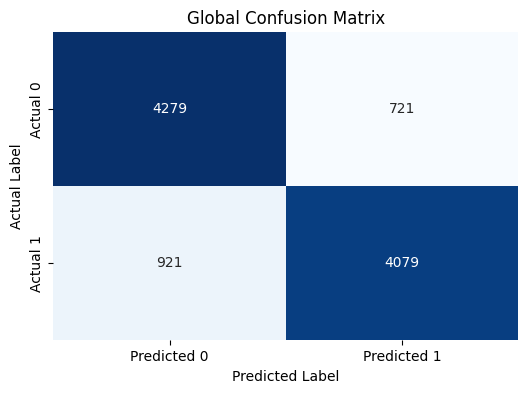


 2. FAIRNESS (GROUP-WISE) MATRICES


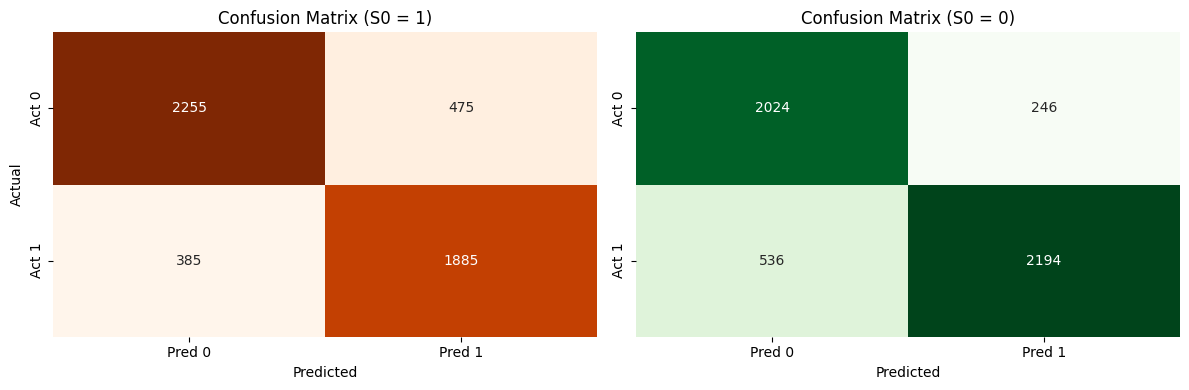

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*40)
print(" 1. GLOBAL CONFUSION METRICS")
print("="*40)

# Generate the global confusion matrix
cm_global = confusion_matrix(y_train, predictions)

# Print the detailed classification report
print("\nClassification Report (Overall):")
print(classification_report(y_train, predictions))

# Plot the Global Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Global Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

print("\n" + "="*40)
print(" 2. FAIRNESS (GROUP-WISE) MATRICES")
print("="*40)

# Generate matrices for each protected group (S0=0 and S0=1)
mask_group_1 = (X_train_combined[:, 0] == 1)
mask_group_0 = (X_train_combined[:, 0] == 0)

cm_group_1 = confusion_matrix(y_train[mask_group_1], predictions[mask_group_1])
cm_group_0 = confusion_matrix(y_train[mask_group_0], predictions[mask_group_0])

# Plot the Group Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_group_1, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Act 0', 'Act 1'])
axes[0].set_title('Confusion Matrix (S0 = 1)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_group_0, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Act 0', 'Act 1'])
axes[1].set_title('Confusion Matrix (S0 = 0)')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [1]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("Recalculating probabilities for the ROC Curve...")
# We must use predict_proba to get the raw confidence percentages!
# [:, 1] grabs the probability of the positive class (Class 1)
probabilities = fairpfn.predict_proba(X_train_tensor)[:, 1]

# Calculate the actual curve points
fpr, tpr, thresholds = roc_curve(y_train, probabilities)
roc_auc = auc(fpr, tpr)

# Initialize the plot
plt.figure(figsize=(8, 6))

# Plot our FairPFN model
plt.plot(fpr, tpr, lw=2, label=f'FairPFN (AUC = {roc_auc:.3f})')

# Plot the "Random Guessing" baseline (the diagonal line)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, label='Random Guess (AUC = 0.500)')

# Formatting the chart
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.xlabel('False Positive Rate (FPR) \n← Better | Worse →', fontsize=12)
plt.ylabel('True Positive Rate (TPR) \n← Worse | Better →', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

# Display the plot
plt.tight_layout()
plt.show()

Recalculating probabilities for the ROC Curve...


NameError: name 'fairpfn' is not defined

# Performance evaluation with more datasets:

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import warnings
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix
)
from scripts.transformer_prediction_interface.base import FairPFNClassifier

# Suppress warnings to keep the console output clean during a massive batch run
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
input_folder = "synthetic_data"
output_file = "fairpfn_results.csv"

# Find all CSV datasets in the input folder (ignoring zip files automatically)
dataset_files = glob.glob(os.path.join(input_folder, "*.csv"))
print(f"Found {len(dataset_files)} CSV datasets to process.")

# Initialize the FairPFN model ONCE to save massive amounts of overhead time
print("Initializing FairPFN model...")
fairpfn = FairPFNClassifier()

# This list will hold a dictionary of results for each dataset
master_results = []

# ==========================================
# 2. BATCH PROCESSING LOOP
# ==========================================
for file_path in dataset_files:
    dataset_name = os.path.basename(file_path)
    print(f"\nProcessing: {dataset_name} ...")
    
    try:
        # Load dataset
        df = pd.read_csv(file_path)
        
        # --- DYNAMIC FEATURE DISCOVERY ---
        s_cols = [col for col in df.columns if col.startswith('S')]
        x_cols = [col for col in df.columns if col.startswith('X')]
        u_cols = [col for col in df.columns if col.startswith('U') or col.lower() == 'u']
        
        if 'Y' not in df.columns or len(s_cols) == 0:
            print(f"  [SKIPPED] Missing 'Y' or 'S' columns.")
            continue
            
        # Get target variable
        y_train = df['Y'].values
        
        # Select Protected Attribute (Enforce S0 if it exists, otherwise grab the first S column)
        s_target = 'S0' if 'S0' in s_cols else s_cols[0]
        A_train = df[[s_target]]
        
        # Select Observable Features
        X_features = df[x_cols]
        
        # Combine: S_target MUST be at index 0. All other S and U variables are dropped.
        X_train_combined = pd.concat([A_train, X_features], axis=1).values
        
        # Convert to Tensor for FairPFN
        X_train_tensor = torch.tensor(X_train_combined, dtype=torch.float32)
        
        # --- MODEL INFERENCE ---
        fairpfn.fit(X_train_tensor, y_train)
        predictions = fairpfn.predict(X_train_tensor)
        
        # Handle probabilities for AUC safely
        if hasattr(fairpfn, 'predict_proba'):
            probs = fairpfn.predict_proba(X_train_tensor)
            prob_preds = probs[:, 1] if len(probs.shape) > 1 else probs
        else:
            prob_preds = predictions
            
        # --- 1. PREDICTION METRICS ---
        auc = roc_auc_score(y_train, prob_preds)
        acc = accuracy_score(y_train, predictions)
        prec = precision_score(y_train, predictions, zero_division=0)
        rec = recall_score(y_train, predictions, zero_division=0)
        f1 = f1_score(y_train, predictions, zero_division=0)
        
        # --- 2. FAIRNESS METRICS ---
        # Identify groups based on the protected attribute (Index 0)
        group_1_mask = (X_train_combined[:, 0] == 1)
        group_0_mask = (X_train_combined[:, 0] == 0)
        
        # Positive prediction rates per group
        rate_1 = np.mean(predictions[group_1_mask]) if np.sum(group_1_mask) > 0 else 0
        rate_0 = np.mean(predictions[group_0_mask]) if np.sum(group_0_mask) > 0 else 0
        
        # Statistical Parity Difference (ATE) -> Ideal value is 0.0
        stat_parity_diff = abs(rate_1 - rate_0)
        
        # Disparate Impact Ratio -> Ideal value is 1.0 (Watch out for division by zero)
        disp_impact = (rate_1 / rate_0) if rate_0 > 0 else float('inf')
        
        # Equal Opportunity Difference (Difference in True Positive Rates) -> Ideal is 0.0
        # Calculate TPR for Group 1
        y_true_1 = y_train[group_1_mask]
        y_pred_1 = predictions[group_1_mask]
        tpr_1 = recall_score(y_true_1, y_pred_1, zero_division=0) if len(y_true_1) > 0 else 0
        
        # Calculate TPR for Group 0
        y_true_0 = y_train[group_0_mask]
        y_pred_0 = predictions[group_0_mask]
        tpr_0 = recall_score(y_true_0, y_pred_0, zero_division=0) if len(y_true_0) > 0 else 0
        
        equal_opp_diff = abs(tpr_1 - tpr_0)
        
        # --- RECORD DATA ---
        master_results.append({
            "model_name": "FairPFN",
            "name_dataset": dataset_name,
            "n_S": len(s_cols),
            "n_X": len(x_cols),
            "n_U": len(u_cols),
            "total_samples": len(df),
            # Prediction Indicators
            "ROC_AUC": round(auc, 4),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1_Score": round(f1, 4),
            # Fairness Indicators
            "Statistical_Parity_Diff_(ATE)": round(stat_parity_diff, 4),
            "Disparate_Impact_Ratio": round(disp_impact, 4),
            "Equal_Opportunity_Diff": round(equal_opp_diff, 4),
            "Pos_Rate_S1": round(rate_1, 4),
            "Pos_Rate_S0": round(rate_0, 4)
        })
        
        print(f"  [SUCCESS] AUC: {auc:.3f} | ATE: {stat_parity_diff:.3f}")
        
    except Exception as e:
        print(f"  [ERROR] Failed to process. Reason: {str(e)}")

# ==========================================
# 3. SAVE AGGREGATED RESULTS TO CSV
# ==========================================
if len(master_results) > 0:
    results_df = pd.DataFrame(master_results)
    
    # Check if the file already exists (so we can append later when running XGBoost)
    file_exists = os.path.isfile(output_file)
    
    # Save to CSV. Mode 'a' appends if exists, 'w' writes new.
    results_df.to_csv(output_file, mode='a', header=not file_exists, index=False)
    
    print("\n" + "="*50)
    print(f"ALL JOBS COMPLETE! Processed {len(master_results)} datasets successfully.")
    print(f"Results appended to: {output_file}")
    print("="*50)
else:
    print("\nNo datasets were successfully processed.")

Found 8 CSV datasets to process.
Initializing FairPFN model...

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_0_8_nodes_full_data.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [SUCCESS] AUC: 0.894 | ATE: 0.016

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p5_seed_0_8_nodes_full_data.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

...

  [ERROR] Failed to process. Reason: [enforce fail at ..\c10\core\impl\alloc_cpu.cpp:72] data. DefaultCPUAllocator: not enough memory: you tried to allocate 9600000000 bytes.

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_20_base_nodes_u_1p0_seed_0_18_nodes_full_data.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [ERROR] Failed to process. Reason: [enforce fail at ..\c10\core\impl\alloc_cpu.cpp:72] data. DefaultCPUAllocator: not enough memory: you tried to allocate 9600000000 bytes.

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_20_base_nodes_u_2p0_seed_0_18_nodes_full_data.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [ERROR] Failed to process. Reason: [enforce fail at ..\c10\core\impl\alloc_cpu.cpp:72] data. DefaultCPUAllocator: not enough memory: you tried to allocate 9600000000 bytes.

ALL JOBS COMPLETE! Processed 4 datasets successfully.
Results appended to: fairpfn_results.csv


# 2nd trial

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)
from scripts.transformer_prediction_interface.base import FairPFNClassifier

# Suppress warnings to keep the console output clean during a massive batch run
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
input_folder = "synthetic_data"
output_file = "fairpfn_results.csv"

# Find all CSV datasets in the input folder (ignoring zip files automatically)
dataset_files = glob.glob(os.path.join(input_folder, "*.csv"))
print(f"Found {len(dataset_files)} CSV datasets to process.")

# Initialize the FairPFN model ONCE to save massive amounts of overhead time
print("Initializing FairPFN model...")
fairpfn = FairPFNClassifier()

# This list will hold a dictionary of results for each dataset
master_results = []

# ==========================================
# 2. BATCH PROCESSING LOOP
# ==========================================
for file_path in dataset_files:
    dataset_name = os.path.basename(file_path)
    print(f"\nProcessing: {dataset_name} ...")
    
    try:
        # Load dataset
        df = pd.read_csv(file_path)
        
        # --- DYNAMIC FEATURE DISCOVERY ---
        s_cols = [col for col in df.columns if col.startswith('S')]
        x_cols = [col for col in df.columns if col.startswith('X')]
        u_cols = [col for col in df.columns if col.startswith('U') or col.lower() == 'u']
        
        if 'Y' not in df.columns or len(s_cols) == 0:
            print(f"  [SKIPPED] Missing 'Y' or 'S' columns.")
            continue
            
        # Get target variable
        y_data = df['Y'].values
        
        # Select Protected Attribute (Enforce S0 if it exists, otherwise grab the first S column)
        s_target = 'S0' if 'S0' in s_cols else s_cols[0]
        A_train = df[[s_target]]
        
        # Select Observable Features
        X_features = df[x_cols]
        
        # Combine: S_target MUST be at index 0. All other S and U variables are dropped.
        X_combined = pd.concat([A_train, X_features], axis=1).values
        
        # --- OOM PREVENTION & ML BEST PRACTICES ---
        # 1. TabPFN scales quadratically. We MUST limit the training context size.
        # Max context is 1000, or 80% of the dataset if it's smaller.
        train_size = min(1000, int(len(X_combined) * 0.8))
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_combined, y_data, train_size=train_size, random_state=42, stratify=y_data
        )
        
        # Convert to Tensors
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        
        # --- MODEL INFERENCE ---
        # Feed the context data so FairPFN can learn the rules
        fairpfn.fit(X_train_tensor, y_train)
        
        # 2. Chunked Prediction: Predict test data in tiny batches to prevent RAM explosion
        BATCH_SIZE = 256
        all_probs = []
        
        for i in range(0, len(X_test_tensor), BATCH_SIZE):
            X_batch = X_test_tensor[i:i+BATCH_SIZE]
            
            # Predict probabilities for the batch
            if hasattr(fairpfn, 'predict_proba'):
                batch_probs = fairpfn.predict_proba(X_batch)
            else:
                # Fallback if predict_proba is completely missing (unlikely, but safe)
                batch_preds = fairpfn.predict(X_batch)
                batch_probs = np.zeros((len(batch_preds), 2))
                batch_probs[np.arange(len(batch_preds)), batch_preds] = 1.0
                
            all_probs.append(batch_probs)
            
        # Stack the chunked results back together
        probs = np.vstack(all_probs)
        
        # Derive predictions from probabilities
        predictions = np.argmax(probs, axis=1) # Class 0 or 1
        prob_preds = probs[:, 1] if len(probs.shape) > 1 else probs
            
        # --- 1. PREDICTION METRICS (Evaluated on the unseen TEST set) ---
        auc = roc_auc_score(y_test, prob_preds)
        acc = accuracy_score(y_test, predictions)
        prec = precision_score(y_test, predictions, zero_division=0)
        rec = recall_score(y_test, predictions, zero_division=0)
        f1 = f1_score(y_test, predictions, zero_division=0)
        
        # --- 2. FAIRNESS METRICS ---
        # Identify groups based on the protected attribute (Index 0 of TEST set)
        group_1_mask = (X_test[:, 0] == 1)
        group_0_mask = (X_test[:, 0] == 0)
        
        # Positive prediction rates per group
        rate_1 = np.mean(predictions[group_1_mask]) if np.sum(group_1_mask) > 0 else 0
        rate_0 = np.mean(predictions[group_0_mask]) if np.sum(group_0_mask) > 0 else 0
        
        # Statistical Parity Difference (ATE) -> Ideal value is 0.0
        stat_parity_diff = abs(rate_1 - rate_0)
        
        # Disparate Impact Ratio -> Ideal value is 1.0
        disp_impact = (rate_1 / rate_0) if rate_0 > 0 else float('inf')
        
        # Equal Opportunity Difference (Difference in True Positive Rates) -> Ideal is 0.0
        y_true_1 = y_test[group_1_mask]
        y_pred_1 = predictions[group_1_mask]
        tpr_1 = recall_score(y_true_1, y_pred_1, zero_division=0) if len(y_true_1) > 0 else 0
        
        y_true_0 = y_test[group_0_mask]
        y_pred_0 = predictions[group_0_mask]
        tpr_0 = recall_score(y_true_0, y_pred_0, zero_division=0) if len(y_true_0) > 0 else 0
        
        equal_opp_diff = abs(tpr_1 - tpr_0)
        
        # --- RECORD DATA ---
        master_results.append({
            "model_name": "FairPFN",
            "name_dataset": dataset_name,
            "n_S": len(s_cols),
            "n_X": len(x_cols),
            "n_U": len(u_cols),
            "total_samples": len(df),
            # Prediction Indicators
            "ROC_AUC": round(auc, 4),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1_Score": round(f1, 4),
            # Fairness Indicators
            "Statistical_Parity_Diff_(ATE)": round(stat_parity_diff, 4),
            "Disparate_Impact_Ratio": round(disp_impact, 4),
            "Equal_Opportunity_Diff": round(equal_opp_diff, 4),
            "Pos_Rate_S1": round(rate_1, 4),
            "Pos_Rate_S0": round(rate_0, 4)
        })
        
        print(f"  [SUCCESS] AUC: {auc:.3f} | ATE: {stat_parity_diff:.3f}")
        
    except Exception as e:
        print(f"  [ERROR] Failed to process. Reason: {str(e)}")

# ==========================================
# 3. SAVE AGGREGATED RESULTS TO CSV
# ==========================================
if len(master_results) > 0:
    results_df = pd.DataFrame(master_results)
    
    # Check if the file already exists (so we can append later when running other models)
    file_exists = os.path.isfile(output_file)
    
    # Save to CSV. Mode 'a' appends if exists, 'w' writes new.
    results_df.to_csv(output_file, mode='a', header=not file_exists, index=False)
    
    print("\n" + "="*50)
    print(f"ALL JOBS COMPLETE! Processed {len(master_results)} datasets successfully.")
    print(f"Results appended to: {output_file}")
    print("="*50)
else:
    print("\nNo datasets were successfully processed.")

Found 8 CSV datasets to process.
Initializing FairPFN model...

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_6_8_nodes_full_data.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [SUCCESS] AUC: 0.879 | ATE: 0.197

ALL JOBS COMPLETE! Processed 8 datasets successfully.
Results appended to: fairpfn_results.csv


# Semi-synthetic data:

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import warnings
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)
from scripts.transformer_prediction_interface.base import FairPFNClassifier

# Suppress warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
input_folder ="semi_synthetic_data" #r"C:\Users\patri\Documents\Master Semesters\2nd semester\APA\model_testing\HR_Simulation_Datasets"
output_file = "fairpfn_semi_syn_results.csv"

# Find all CSV datasets
dataset_files = glob.glob(os.path.join(input_folder, "*.csv"))
print(f"Found {len(dataset_files)} semi-synthetic datasets to process.")

# Initialize FairPFN once
print("Initializing FairPFN model...")
fairpfn = FairPFNClassifier()

master_results = []

# ==========================================
# 2. BATCH PROCESSING LOOP
# ==========================================
for file_path in dataset_files:
    dataset_name = os.path.basename(file_path)
    print(f"\nProcessing: {dataset_name} ...")
    
    try:
        # Load dataset
        df = pd.read_csv(file_path)
        
        # --- FILENAME PARAMETER EXTRACTION ---
        # Example: HR_N1000_HighBias_Thresh1.0_Seed100_BIASED_ALL.csv
        name_no_ext = dataset_name.replace('.csv', '')
        
        # Extract Bias Level
        bias_level = "Unknown"
        if "HighBias" in name_no_ext: bias_level = "HighBias"
        elif "LowBias" in name_no_ext: bias_level = "LowBias"
            
        # Extract Threshold
        thresh_match = re.search(r'Thresh([\d\.]+)', name_no_ext)
        threshold = thresh_match.group(1) if thresh_match else "Unknown"
        
        # Extract Data Type
        data_type = "Unknown"
        if "BIASED_ALL" in name_no_ext: data_type = "BIASED_ALL"
        elif "FAIR_ALL" in name_no_ext: data_type = "FAIR_ALL"

        # --- DYNAMIC FEATURE DISCOVERY (SEMI-SYNTHETIC SCHEMA) ---
        # Target: Y (e.g., Y_Target)
        y_cols = [col for col in df.columns if col.startswith('Y')]
        if not y_cols:
            print("  [SKIPPED] Missing 'Y' target column.")
            continue
            
        y_data = df[y_cols[0]].values
        
        # Protected Attributes (S and G, e.g., S_ImmigStatus, G_Gender)
        s_cols = [col for col in df.columns if col.startswith('S') or col.startswith('G')]
        s_target_list = [col for col in df.columns if col.startswith('S')]
        
        if not s_target_list:
            print("  [SKIPPED] Missing 'S' (Immigration Status) column.")
            continue
            
        # We explicitly use the 'S' column as the primary protected attribute for FairPFN
        s_target = s_target_list[0]
        A_train = df[[s_target]]
        
        # Observable Features (Start with X_)
        x_cols = [col for col in df.columns if col.startswith('X_')]
        X_features = df[x_cols]
        
        # Unobserved / Hidden Variables (Start with U_, H_, C_)
        u_cols = [col for col in df.columns if col.startswith(('U_', 'H_', 'C_'))]
        
        # Combine: S MUST be at index 0. All other S (like G) and U variables are dropped.
        X_combined = pd.concat([A_train, X_features], axis=1).values
        
        # --- TRAIN/TEST SPLIT & MEMORY PROTECTION ---
        train_size = min(1000, int(len(X_combined) * 0.8))
        X_train, X_test, y_train, y_test = train_test_split(
            X_combined, y_data, train_size=train_size, random_state=42, stratify=y_data
        )
        
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        
        # --- MODEL INFERENCE ---
        fairpfn.fit(X_train_tensor, y_train)
        
        BATCH_SIZE = 256
        all_probs = []
        
        for i in range(0, len(X_test_tensor), BATCH_SIZE):
            X_batch = X_test_tensor[i:i+BATCH_SIZE]
            
            if hasattr(fairpfn, 'predict_proba'):
                batch_probs = fairpfn.predict_proba(X_batch)
            else:
                batch_preds = fairpfn.predict(X_batch)
                batch_probs = np.zeros((len(batch_preds), 2))
                batch_probs[np.arange(len(batch_preds)), batch_preds] = 1.0
                
            all_probs.append(batch_probs)
            
        probs = np.vstack(all_probs)
        predictions = np.argmax(probs, axis=1)
        prob_preds = probs[:, 1] if len(probs.shape) > 1 else probs
            
        # --- 1. PREDICTION METRICS (TEST set) ---
        auc = roc_auc_score(y_test, prob_preds)
        acc = accuracy_score(y_test, predictions)
        prec = precision_score(y_test, predictions, zero_division=0)
        rec = recall_score(y_test, predictions, zero_division=0)
        f1 = f1_score(y_test, predictions, zero_division=0)
        
        # --- 2. FAIRNESS METRICS ---
        # Group 1 = Advantaged/Group A (S=1), Group 0 = Disadvantaged/Group B (S=0)
        group_1_mask = (X_test[:, 0] == 1)
        group_0_mask = (X_test[:, 0] == 0)
        
        rate_1 = np.mean(predictions[group_1_mask]) if np.sum(group_1_mask) > 0 else 0
        rate_0 = np.mean(predictions[group_0_mask]) if np.sum(group_0_mask) > 0 else 0
        
        stat_parity_diff = abs(rate_1 - rate_0)
        disp_impact = (rate_1 / rate_0) if rate_0 > 0 else float('inf')
        
        y_true_1, y_pred_1 = y_test[group_1_mask], predictions[group_1_mask]
        tpr_1 = recall_score(y_true_1, y_pred_1, zero_division=0) if len(y_true_1) > 0 else 0
        
        y_true_0, y_pred_0 = y_test[group_0_mask], predictions[group_0_mask]
        tpr_0 = recall_score(y_true_0, y_pred_0, zero_division=0) if len(y_true_0) > 0 else 0
        
        equal_opp_diff = abs(tpr_1 - tpr_0)
        
        # --- RECORD DATA ---
        master_results.append({
            "model_name": "FairPFN",
            "name_dataset": dataset_name,
            # Extracted Parameters
            "bias_level": bias_level,
            "threshold": threshold,
            "data_type": data_type,
            # Schema Counters
            "n_S": len(s_cols),
            "n_X": len(x_cols),
            "n_U": len(u_cols),
            "total_samples": len(df),
            # Prediction Indicators
            "ROC_AUC": round(auc, 4),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1_Score": round(f1, 4),
            # Fairness Indicators
            "Statistical_Parity_Diff_(ATE)": round(stat_parity_diff, 4),
            "Disparate_Impact_Ratio": round(disp_impact, 4),
            "Equal_Opportunity_Diff": round(equal_opp_diff, 4),
            "Pos_Rate_S1": round(rate_1, 4),
            "Pos_Rate_S0": round(rate_0, 4)
        })
        
        print(f"  [SUCCESS] AUC: {auc:.3f} | ATE: {stat_parity_diff:.3f}")
        
    except Exception as e:
        print(f"  [ERROR] Failed to process. Reason: {str(e)}")

# ==========================================
# 3. SAVE AGGREGATED RESULTS TO CSV
# ==========================================
if len(master_results) > 0:
    results_df = pd.DataFrame(master_results)
    
    file_exists = os.path.isfile(output_file)
    results_df.to_csv(output_file, mode='a', header=not file_exists, index=False)
    
    print("\n" + "="*50)
    print(f"ALL JOBS COMPLETE! Processed {len(master_results)} datasets successfully.")
    print(f"Results appended to: {output_file}")
    print("="*50)
else:
    print("\nNo datasets were successfully processed.")

Found 800 semi-synthetic datasets to process.
Initializing FairPFN model...

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_BIASED_ALL.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [SUCCESS] AUC: 0.902 | ATE: 0.030

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_BIASED_FAIRNESS.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [SUCCESS] AUC: 0.902 | ATE: 0.030

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_BIASED_MASKED.csv ...
  [SKIPPED] Missing 'S' (Immigration Status) column.

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_FAIR_ALL.csv ...


...

  [SUCCESS] AUC: 0.768 | ATE: 0.019

Processing: HR_N1000_WealthDom_Thresh2.5_Seed900_BIASED_FAIRNESS.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [SUCCESS] AUC: 0.768 | ATE: 0.019

Processing: HR_N1000_WealthDom_Thresh2.5_Seed900_BIASED_MASKED.csv ...
  [SKIPPED] Missing 'S' (Immigration Status) column.

Processing: HR_N1000_WealthDom_Thresh2.5_Seed900_FAIR_ALL.csv ...


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

  [SUCCESS] AUC: 0.737 | ATE: 0.000

ALL JOBS COMPLETE! Processed 600 datasets successfully.
Results appended to: fairpfn_semi_syn_results.csv


# XGBoost

### Purely Synthetic data:

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import warnings
import sys
import types

# --- XGBoost compatibility fix for missing pkg_resources ---
# Jupyter sometimes loads a broken/partial pkg_resources in the background.
# This forces the patch regardless of whether it was already loaded.
if 'pkg_resources' not in sys.modules:
    sys.modules['pkg_resources'] = types.ModuleType('pkg_resources')

import pkg_resources

if not hasattr(pkg_resources, 'DistributionNotFound'):
    class DistributionNotFound(Exception): pass
    pkg_resources.DistributionNotFound = DistributionNotFound

if not hasattr(pkg_resources, 'get_distribution'):
    def get_distribution(name):
        raise pkg_resources.DistributionNotFound()
    pkg_resources.get_distribution = get_distribution
# ----------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)
from xgboost import XGBClassifier

# Suppress warnings to keep the console output clean during a massive batch run
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
input_folder = "synthetic_data"
output_file = "xgb_syn_results.csv"

# Find all CSV datasets in the input folder (ignoring zip files automatically)
dataset_files = glob.glob(os.path.join(input_folder, "*.csv"))
print(f"Found {len(dataset_files)} CSV datasets to process.")

# Initialize the XGBoost model ONCE
print("Initializing XGBoost model...")
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# This list will hold a dictionary of results for each dataset
master_results = []

# ==========================================
# 2. BATCH PROCESSING LOOP
# ==========================================
for file_path in dataset_files:
    dataset_name = os.path.basename(file_path)
    print(f"\nProcessing: {dataset_name} ...")
    
    try:
        # Load dataset
        df = pd.read_csv(file_path)
        
        # --- DYNAMIC FEATURE DISCOVERY ---
        s_cols = [col for col in df.columns if col.startswith('S')]
        x_cols = [col for col in df.columns if col.startswith('X')]
        u_cols = [col for col in df.columns if col.startswith('U') or col.lower() == 'u']
        
        if 'Y' not in df.columns or len(s_cols) == 0:
            print(f"  [SKIPPED] Missing 'Y' or 'S' columns.")
            continue
            
        # Get target variable
        y_data = df['Y'].values
        
        # Select Protected Attribute (Enforce S0 if it exists, otherwise grab the first S column)
        s_target = 'S0' if 'S0' in s_cols else s_cols[0]
        A_train = df[[s_target]]
        
        # Select Observable Features
        X_features = df[x_cols]
        
        # Combine: S_target MUST be at index 0. All other S and U variables are dropped.
        X_combined = pd.concat([A_train, X_features], axis=1).values
        
        # --- ML BEST PRACTICES ---
        train_size = min(1000, int(len(X_combined) * 0.8))
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_combined, y_data, train_size=train_size, random_state=42, stratify=y_data
        )
        
        # --- MODEL INFERENCE ---
        # Feed the context data so XGBoost can learn the rules
        xgb_model.fit(X_train, y_train)
        
        # XGBoost handles predictions fast, no chunking needed
        probs = xgb_model.predict_proba(X_test)
        predictions = xgb_model.predict(X_test)
        prob_preds = probs[:, 1] if len(probs.shape) > 1 else probs
            
        # --- 1. PREDICTION METRICS (Evaluated on the unseen TEST set) ---
        auc = roc_auc_score(y_test, prob_preds)
        acc = accuracy_score(y_test, predictions)
        prec = precision_score(y_test, predictions, zero_division=0)
        rec = recall_score(y_test, predictions, zero_division=0)
        f1 = f1_score(y_test, predictions, zero_division=0)
        
        # --- 2. FAIRNESS METRICS ---
        # Identify groups based on the protected attribute (Index 0 of TEST set)
        group_1_mask = (X_test[:, 0] == 1)
        group_0_mask = (X_test[:, 0] == 0)
        
        # Positive prediction rates per group
        rate_1 = np.mean(predictions[group_1_mask]) if np.sum(group_1_mask) > 0 else 0
        rate_0 = np.mean(predictions[group_0_mask]) if np.sum(group_0_mask) > 0 else 0
        
        # Statistical Parity Difference (ATE) -> Ideal value is 0.0
        stat_parity_diff = abs(rate_1 - rate_0)
        
        # Disparate Impact Ratio -> Ideal value is 1.0
        disp_impact = (rate_1 / rate_0) if rate_0 > 0 else float('inf')
        
        # Equal Opportunity Difference (Difference in True Positive Rates) -> Ideal is 0.0
        y_true_1 = y_test[group_1_mask]
        y_pred_1 = predictions[group_1_mask]
        tpr_1 = recall_score(y_true_1, y_pred_1, zero_division=0) if len(y_true_1) > 0 else 0
        
        y_true_0 = y_test[group_0_mask]
        y_pred_0 = predictions[group_0_mask]
        tpr_0 = recall_score(y_true_0, y_pred_0, zero_division=0) if len(y_true_0) > 0 else 0
        
        equal_opp_diff = abs(tpr_1 - tpr_0)
        
        # --- RECORD DATA ---
        master_results.append({
            "model_name": "XGBoost",
            "name_dataset": dataset_name,
            "n_S": len(s_cols),
            "n_X": len(x_cols),
            "n_U": len(u_cols),
            "total_samples": len(df),
            # Prediction Indicators
            "ROC_AUC": round(auc, 4),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1_Score": round(f1, 4),
            # Fairness Indicators
            "Statistical_Parity_Diff_(ATE)": round(stat_parity_diff, 4),
            "Disparate_Impact_Ratio": round(disp_impact, 4),
            "Equal_Opportunity_Diff": round(equal_opp_diff, 4),
            "Pos_Rate_S1": round(rate_1, 4),
            "Pos_Rate_S0": round(rate_0, 4)
        })
        
        print(f"  [SUCCESS] AUC: {auc:.3f} | ATE: {stat_parity_diff:.3f}")
        
    except Exception as e:
        print(f"  [ERROR] Failed to process. Reason: {str(e)}")

# ==========================================
# 3. SAVE AGGREGATED RESULTS TO CSV
# ==========================================
if len(master_results) > 0:
    results_df = pd.DataFrame(master_results)
    
    # Check if the file already exists
    file_exists = os.path.isfile(output_file)
    
    # Save to CSV. Mode 'a' appends if exists, 'w' writes new.
    results_df.to_csv(output_file, mode='a', header=not file_exists, index=False)
    
    print("\n" + "="*50)
    print(f"ALL JOBS COMPLETE! Processed {len(master_results)} datasets successfully.")
    print(f"Results appended to: {output_file}")
    print("="*50)
else:
    print("\nNo datasets were successfully processed.")

Found 64 CSV datasets to process.
Initializing XGBoost model...

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_2_8_nodes_full_data.csv ...
  [SUCCESS] AUC: 0.948 | ATE: 0.024

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_3_8_nodes_full_data.csv ...
  [SUCCESS] AUC: 0.913 | ATE: 0.136

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_4_8_nodes_full_data.csv ...
  [SUCCESS] AUC: 0.988 | ATE: 0.375

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_5_8_nodes_full_data.csv ...
  [SUCCESS] AUC: 0.932 | ATE: 0.013

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_6_8_nodes_full_data.csv ...
  [SUCCESS] AUC: 0.907 | ATE: 0.192

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_50%_10_base_nodes_u_0p0_seed_7_8_nodes_full_data.csv ...
  [SUCCESS] AUC: 0.986 | ATE: 0.453

Processing: SF_Large_Sample_Size_Dataset_Linear_ReLU_

### Semi-synthetic data:

In [6]:
import os
import glob
import pandas as pd
import numpy as np
import warnings
import sys
import types
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)
from xgboost import XGBClassifier

# --- XGBoost compatibility fix for missing pkg_resources ---
if 'pkg_resources' not in sys.modules:
    sys.modules['pkg_resources'] = types.ModuleType('pkg_resources')

import pkg_resources

if not hasattr(pkg_resources, 'DistributionNotFound'):
    class DistributionNotFound(Exception): pass
    pkg_resources.DistributionNotFound = DistributionNotFound

if not hasattr(pkg_resources, 'get_distribution'):
    def get_distribution(name):
        raise pkg_resources.DistributionNotFound()
    pkg_resources.get_distribution = get_distribution
# ----------------------------------------------------------

# Suppress warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
input_folder = "semi_synthetic_data"
output_file = "xgb_semi_syn_results.csv"

dataset_files = glob.glob(os.path.join(input_folder, "*.csv"))
print(f"Found {len(dataset_files)} semi-synthetic datasets to process.")

print("Initializing XGBoost model...")
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

master_results = []

# ==========================================
# 2. BATCH PROCESSING LOOP
# ==========================================
for file_path in dataset_files:
    dataset_name = os.path.basename(file_path)
    print(f"\nProcessing: {dataset_name} ...")
    
    try:
        df = pd.read_csv(file_path)
        
        # --- FILENAME PARAMETER EXTRACTION ---
        name_no_ext = dataset_name.replace('.csv', '')
        bias_level = "HighBias" if "HighBias" in name_no_ext else ("LowBias" if "LowBias" in name_no_ext else "Unknown")
        thresh_match = re.search(r'Thresh([\d\.]+)', name_no_ext)
        threshold = thresh_match.group(1) if thresh_match else "Unknown"
        data_type = "BIASED_ALL" if "BIASED_ALL" in name_no_ext else ("FAIR_ALL" if "FAIR_ALL" in name_no_ext else "Unknown")

        # --- DYNAMIC FEATURE DISCOVERY ---
        y_cols = [col for col in df.columns if col.startswith('Y')]
        if not y_cols:
            print("  [SKIPPED] Missing 'Y' target column.")
            continue
            
        y_data = df[y_cols[0]].values
        
        # Identify protected attribute (Look for S or G)
        s_target_list = [col for col in df.columns if col.startswith('S')]
        if not s_target_list:
            print("  [SKIPPED] Missing 'S' column.")
            continue
            
        s_target = s_target_list[0]
        A_train = df[[s_target]]
        
        x_cols = [col for col in df.columns if col.startswith('X_')]
        X_features = df[x_cols]
        u_cols = [col for col in df.columns if col.startswith(('U_', 'H_', 'C_'))]
        
        X_combined = pd.concat([A_train, X_features], axis=1).values
        
        # --- MODEL INFERENCE ---
        X_train, X_test, y_train, y_test = train_test_split(
            X_combined, y_data, train_size=min(1000, int(len(X_combined) * 0.8)), 
            random_state=42, stratify=y_data
        )
        
        xgb_model.fit(X_train, y_train)
        
        probs = xgb_model.predict_proba(X_test)
        predictions = xgb_model.predict(X_test)
        prob_preds = probs[:, 1] if len(probs.shape) > 1 else probs
            
        # --- METRICS ---
        auc = roc_auc_score(y_test, prob_preds)
        acc = accuracy_score(y_test, predictions)
        prec = precision_score(y_test, predictions, zero_division=0)
        rec = recall_score(y_test, predictions, zero_division=0)
        f1 = f1_score(y_test, predictions, zero_division=0)
        
        # Fairness
        group_1_mask = (X_test[:, 0] == 1)
        group_0_mask = (X_test[:, 0] == 0)
        rate_1 = np.mean(predictions[group_1_mask]) if np.sum(group_1_mask) > 0 else 0
        rate_0 = np.mean(predictions[group_0_mask]) if np.sum(group_0_mask) > 0 else 0
        
        stat_parity_diff = abs(rate_1 - rate_0)
        disp_impact = (rate_1 / rate_0) if rate_0 > 0 else float('inf')
        
        tpr_1 = recall_score(y_test[group_1_mask], predictions[group_1_mask], zero_division=0) if np.sum(group_1_mask) > 0 else 0
        tpr_0 = recall_score(y_test[group_0_mask], predictions[group_0_mask], zero_division=0) if np.sum(group_0_mask) > 0 else 0
        equal_opp_diff = abs(tpr_1 - tpr_0)
        
        master_results.append({
            "model_name": "XGBoost",
            "name_dataset": dataset_name,
            "bias_level": bias_level,
            "threshold": threshold,
            "data_type": data_type,
            "n_S": len(s_target_list),
            "n_X": len(x_cols),
            "n_U": len(u_cols),
            "total_samples": len(df),
            "ROC_AUC": round(auc, 4),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1_Score": round(f1, 4),
            "Statistical_Parity_Diff_(ATE)": round(stat_parity_diff, 4),
            "Disparate_Impact_Ratio": round(disp_impact, 4),
            "Equal_Opportunity_Diff": round(equal_opp_diff, 4),
            "Pos_Rate_S1": round(rate_1, 4),
            "Pos_Rate_S0": round(rate_0, 4)
        })
        
        print(f"  [SUCCESS] AUC: {auc:.3f} | ATE: {stat_parity_diff:.3f}")
        
    except Exception as e:
        print(f"  [ERROR] Failed to process. Reason: {str(e)}")

# ==========================================
# 3. SAVE AGGREGATED RESULTS TO CSV
# ==========================================
if len(master_results) > 0:
    results_df = pd.DataFrame(master_results)
    file_exists = os.path.isfile(output_file)
    results_df.to_csv(output_file, mode='a', header=not file_exists, index=False)
    print(f"\nALL JOBS COMPLETE! Processed {len(master_results)} datasets. Results saved to {output_file}.")

Found 800 semi-synthetic datasets to process.
Initializing XGBoost model...

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_BIASED_ALL.csv ...
  [SUCCESS] AUC: 0.936 | ATE: 0.216

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_BIASED_FAIRNESS.csv ...
  [SUCCESS] AUC: 0.936 | ATE: 0.216

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_BIASED_MASKED.csv ...
  [SKIPPED] Missing 'S' column.

Processing: HR_N1000_HighBias_Thresh1.0_Seed1000_FAIR_ALL.csv ...
  [SUCCESS] AUC: 0.688 | ATE: 0.016

Processing: HR_N1000_HighBias_Thresh1.0_Seed100_BIASED_ALL.csv ...
  [SUCCESS] AUC: 0.894 | ATE: 0.206

Processing: HR_N1000_HighBias_Thresh1.0_Seed100_BIASED_FAIRNESS.csv ...
  [SUCCESS] AUC: 0.894 | ATE: 0.206

Processing: HR_N1000_HighBias_Thresh1.0_Seed100_BIASED_MASKED.csv ...
  [SKIPPED] Missing 'S' column.

Processing: HR_N1000_HighBias_Thresh1.0_Seed100_FAIR_ALL.csv ...
  [SUCCESS] AUC: 0.586 | ATE: 0.051

Processing: HR_N1000_HighBias_Thresh1.0_Seed1100_BIASED_ALL.csv ...
  [SUCCESS] AUC